<a href="https://colab.research.google.com/github/Melaf07/Doctors-Handwriting-Prescription-Recognition-using-TrOCR/blob/main/Doctor_Handwriting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Doctor Handwriting / Prescription Recognition using TrOCR

This notebook fine-tunes the pre-trained **TrOCR model**  
(`microsoft/trocr-base-handwritten`) to recognize doctor handwriting on prescription images.
\
## Objective

- Input: an image of a handwritten prescription.
- Output: the corresponding **medicine name** as text.
- Goal: adapt a general handwritten OCR model to a **custom medical dataset**.

## Dataset

The dataset is stored in Google Drive with the following structure:

- `Training/labels.csv` and `Training/images/`
- `Testing/labels.csv` and `Testing/images/`

Each `labels.csv` contains at least:
- `MEDICINE_NAME`: the target text we want the model to predict.
- `IMAGE`: the filename of the corresponding prescription image.

In this notebook we:

1. Prepare the data (train/validation/test splits and paths).
2. Build a custom PyTorch `Dataset` compatible with TrOCR.
3. Fine-tune TrOCR on our training set.
4. Visualize training and validation loss curves.
5. Evaluate word-level and character-level accuracy on the test set.
6. Show example predictions (image + ground truth + model output).

.



In [1]:
# Environment check
# This cell prints information about the current Python / PyTorch setup.
# It is only for debugging and does NOT change the model or the data.
import torch, platform
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Python:", platform.python_version())


PyTorch: 2.9.0+cu126
CUDA available: True
Python: 3.12.12


## 1. Environment and data setup

In this section we prepare the environment and load the dataset:

- Check Python, PyTorch and CUDA versions (for debugging and reproducibility).
- Mount Google Drive so we can read and write files.
- Install all required Python libraries (Transformers, Torch, etc.).
- Copy the dataset from Google Drive into the Colab runtime (`/content`) to make data loading faster.
- Load the **training** and **testing** label files (`labels.csv`) into pandas DataFrames.
- Split the original training set into:
  - a **training subset** (used to update model weights),
  - and a **validation subset** (used to monitor performance during training).

After these cells, we have three DataFrames:

- `train_df` – training samples
- `val_df`   – validation samples
- `test_df`  – test samples

All of them still contain the original columns (such as `MEDICINE_NAME` and `IMAGE`).


In [2]:
# Mount Google Drive
# This connects Colab to your Google Drive so we can:
#   - read the dataset from Drive
#   - save fine-tuned model checkpoints back to Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install dependencies

In [3]:
# Install all external libraries required by this notebook.
# This needs to be run once per new Colab runtime.
!pip install -q ultralytics==8.3.228 transformers==4.45.2 \
               pillow opencv-python==4.10.0.84 numpy==2.0.2 scipy tqdm==4.67 pyyaml roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 138.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.0 MB/s eta 0:00:00


Copy dataset from Drive to runtime

In [4]:
# Copy dataset from Google Drive to local runtime (/content)
# Reason:
#   - Reading from /content is usually faster than reading directly from Drive.
#   - BASE_DIR is used later as the root folder for all data paths.

import shutil, os

# Original dataset location on Google Drive
SRC = "/content/drive/MyDrive/datasetmidcal"

# Local location inside the Colab runtime
DST = "/content/kaggle_prescription"

# If the dataset was not copied before, copy it now
if not os.path.exists(DST):
    shutil.copytree(SRC, DST)
    print("Copied dataset to", DST)
# If it already exists, reuse it
else:
    print("Local dataset already exists:", DST)

# BASE_DIR will be used in all remaining cells to locate the dataset
BASE_DIR = DST


Copied dataset to /content/kaggle_prescription


Load CSVs

In [5]:
# Load label CSV files for Training and Testing
# Each labels.csv is expected to have at least:
#   - MEDICINE_NAME : ground truth text for the OCR
#   - IMAGE         : file name of the corresponding image

import pandas as pd
import os

train_csv = os.path.join(BASE_DIR, "Training", "labels.csv")
test_csv   = os.path.join(BASE_DIR, "Testing", "labels.csv")

train_df = pd.read_csv(train_csv)
test_df   = pd.read_csv(test_csv)

print("Train columns:", train_df.columns)
print("Test columns:", test_df.columns)
print("Train size:", len(train_df), " Test size:", len(test_df))

Train columns: Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')
Test columns: Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')
Train size: 3120  Test size: 780


Train/Val split

In [6]:
# Split the original training data into train and validation sets
#   - train_df : used to update model weights
#   - val_df   : used to monitor validation loss during training

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2, # 20% of the original training data for validation
    random_state=42,
    shuffle=True
)

print("Train rows:", len(train_df), "Val rows:", len(val_df))


Train rows: 2496 Val rows: 624


## 2. Normalizing label columns (`text` and `image_path`)

The raw CSV files contain:

- `MEDICINE_NAME` → text of the medicine name.
- `IMAGE` → filename of the image.

For easier processing, we create two standardized columns:

- **`text`**  
  This will hold the ground truth string that the OCR model should predict.  
  We simply copy and clean values from `MEDICINE_NAME`.

- **`image_path`**  
  This stores the *full* path to the image file on disk, constructed as:  
  `BASE_DIR / <split_name> / "images" / IMAGE`.

We apply this transformation to:

- `train_df` (Training)
- `val_df`   (Training, used as validation)
- `test_df`  (Testing)

After this step, every row in these DataFrames has:

- the correct **text label** (`text`)
- and the correct **path to its image** (`image_path`).


In [9]:
# Create normalized columns "text" and "image_path"
# After this cell:
#   - train_df, val_df, test_df all contain:
#       * text       : ground truth target string (medicine name)
#       * image_path : full path to the corresponding image file

import os

def add_columns(df, split_name):

    # Use MEDICINE_NAME as the OCR target text.
    df["text"] = df["MEDICINE_NAME"].fillna("").astype(str)

    # Build full path to each image on disk.
    df["image_path"] = df["IMAGE"].apply(
        lambda x: os.path.join(BASE_DIR, split_name, "images", x)
    )
    return df

# Apply standardization to each split
train_df = add_columns(train_df, "Training")
val_df   = add_columns(val_df, "Training")   # val images are also in Training/images
test_df  = add_columns(test_df, "Testing")   # test images come from Testing/images


## 3. TrOCR model and custom Dataset

In this section we prepare the model and the data pipeline.

### 3.1 TrOCR components

We load:

- `TrOCRProcessor`  
  - Prepares images (resize, normalize) for the **encoder**.  
  - Tokenizes and detokenizes text for the **decoder**.

- `VisionEncoderDecoderModel`  
  - A combined model with:
    - a **vision encoder** (for images),
    - and a **text decoder** (for generating the output sequence).

The pre-trained weights (`microsoft/trocr-base-handwritten`) are already trained on general handwritten text.  
Our goal is to **fine-tune** this model on medical prescription handwriting.

### 3.2 Custom PyTorch Dataset (`RxOcrDataset`)

We define a dataset class that:

- Reads one row from a DataFrame (`train_df`, `val_df`, or `test_df`).
- Loads the image from `image_path` and converts it to RGB.
- Uses the `processor` to convert the image into `pixel_values` (tensor) for the encoder.
- Uses the tokenizer to convert the `text` string into a sequence of token IDs (`labels`) for the decoder.
- Replaces padding token IDs with **-100**, so the loss function will ignore those positions.

Each sample returned by this Dataset is a dictionary:

- `"pixel_values"`: image tensor of shape `(3, H, W)`
- `"labels"`: token IDs tensor of shape `(T,)` with `-100` where we want to ignore padding.

We then create:

- `train_dataset` from `train_df`
- `val_dataset`   from `val_df`
- `test_dataset`  from `test_df` (for evaluation later)


In [12]:
# Load pre-trained TrOCR model and define a custom Dataset
# We will fine-tune "microsoft/trocr-base-handwritten" on our prescription data.

from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch

# Processor:
#   - preprocesses images (resize/normalize)
#   - tokenizes and de-tokenizes text for the decoder
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

# VisionEncoderDecoderModel:
#   - encoder: vision part (image)
#   - decoder: text generation
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# Select device for computation
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

class RxOcrDataset(Dataset):
    def __init__(self, df, processor, max_target_length=32):

        # Reset index so __getitem__ works with 0..N-1
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        text = row["text"]

        # Encode image for the encoder
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        # Tokenize target text for the decoder
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_target_length,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        # Replace padding token ID with -100 to mask it from the loss
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}

# Wrap training and validation DataFrames in Dataset objects
train_dataset = RxOcrDataset(train_df, processor)
val_dataset   = RxOcrDataset(val_df, processor)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

VisionEncoderDecoderModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 4. Quick qualitative check (before fine-tuning)

Before training, we define a helper function `predict_text(image_path)` that:

1. Loads a single image from disk.
2. Uses the processor to convert it into `pixel_values`.
3. Calls `model.generate(...)` to let the decoder produce a sequence of token IDs.
4. Decodes the token IDs back into a text string.

We then apply this function to a small random sample of test images and print:

- the image filename,
- the **ground truth** text (`GT`),
- the **current prediction** (`Pred`) from the pre-trained model.

At this stage, the model is **not yet fine-tuned** on our prescription dataset,  
so these predictions provide a baseline reference before training.


In [13]:
# Create test Dataset and define a quick prediction helper.
# Then show a few predictions from the (current) model on random test images.
test_dataset = RxOcrDataset(test_df, processor)

def predict_text(image_path):

    image = Image.open(image_path).convert("RGB")
    with torch.inference_mode():
        pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
        generated_ids = model.generate(pixel_values, max_new_tokens=32)
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return pred

# Sample a few rows from the test set and print ground truth vs prediction
sample_rows = test_df.sample(5, random_state=0)
for _, row in sample_rows.iterrows():
    img_p = row["image_path"]
    gt = row["text"]
    pred = predict_text(img_p)
    print("Image:", os.path.basename(img_p))
    print("GT:   ", gt)
    print("Pred: ", pred)
    print("-" * 50)


Image: 699.png
GT:    Romycin
Pred:  Romaycin
--------------------------------------------------
Image: 327.png
GT:    Filmet
Pred:  thilst
--------------------------------------------------
Image: 210.png
GT:    Denixil
Pred:  Terminal .
--------------------------------------------------
Image: 14.png
GT:    Ace
Pred:  ace
--------------------------------------------------
Image: 413.png
GT:    Ketozol
Pred:  ketoral
--------------------------------------------------


## 5. Fine-tuning setup and training loop

### 5.1 DataLoaders

We use PyTorch `DataLoader` objects to:

- shuffle the **training** data and feed it in mini-batches,
- iterate over the **validation** data without shuffling.

This allows efficient training on the GPU with small batches.

### 5.2 Model configuration

We make sure the model configuration is aligned with the tokenizer:

- `pad_token_id` – the ID used for padding in the decoder.
- `eos_token_id` – the end-of-sequence token.
- `decoder_start_token_id` – the token that starts decoder generation.
- `max_length` – maximum sequence length for generation.

These settings are important so that training and decoding behave correctly.

### 5.3 Fine-tuning loop

We fine-tune the model for a fixed number of epochs (`num_epochs`):

For **each epoch**:

1. **Training phase**
   - Set the model to `train()` mode.
   - For each batch from `train_loader`:
     - Move `pixel_values` and `labels` to the selected device (CPU/GPU).
     - Call `model(pixel_values=pixel_values, labels=labels)`.
       - When `labels` are provided, the model automatically computes the cross-entropy loss.
     - Backpropagate (`loss.backward()`) and update the weights with the optimizer (`optimizer.step()`).
   - Compute the **average training loss** for this epoch and store it in `train_losses`.

2. **Validation phase**
   - Set the model to `eval()` mode to disable dropout.
   - Disable gradient computation with `torch.inference_mode()`.
   - For each batch from `val_loader`, compute the validation loss.
   - Compute the **average validation loss** and store it in `val_losses`.

3. **Checkpoint saving**
   - After each epoch, save the model weights and processor to Google Drive.
   - This allows reloading a specific epoch later without retraining.

The training and validation losses are later used to draw learning curves.


In [15]:
from torch.utils.data import DataLoader

# DataLoaders for training and validation
# You can change batch_size depending on your GPU memory
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True # shuffle training data each epoch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False # validation data does not need shuffling
)

# Show number of batches in each loader
len(train_loader), len(val_loader)


(624, 156)

Configure model tokens

In [16]:
# Make sure the model config matches the processor tokenizer

# Pad token and end-of-sequence token for the decoder
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id

# Some models use bos_token_id, some use cls_token_id as decoder_start_token_id
if processor.tokenizer.bos_token_id is not None:
    model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
else:
    model.config.decoder_start_token_id = processor.tokenizer.cls_token_id

# Optional: limit max generated length (for decoding / generation)
model.config.max_length = 32
model.config.vocab_size = model.config.decoder.vocab_size

print("pad_token_id:", model.config.pad_token_id)
print("eos_token_id:", model.config.eos_token_id)
print("decoder_start_token_id:", model.config.decoder_start_token_id)


pad_token_id: 1
eos_token_id: 2
decoder_start_token_id: 0


Fine-tuning loop

In [ ]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt  # for plotting later


# Fine-tune the TrOCR model on our training data
# This loop:
#   - trains for num_epochs epochs
#   - tracks training and validation loss
#   - saves a checkpoint after each epoch

# Optimizer for fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

num_epochs = 5

# Lists to store history for plotting
train_losses = []
val_losses = []

for epoch in range(1, num_epochs + 1):
    # === Training ===
    model.train()
    train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch} - training"):
        pixel_values = batch["pixel_values"].to(device)  # (B, C, H, W)
        labels = batch["labels"].to(device)              # (B, T)

        # Forward pass: model returns loss when labels are given
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / max(1, len(train_loader))
    train_losses.append(avg_train_loss)  # save for plotting later

    # === Validation ===
    model.eval()
    val_loss = 0.0
    with torch.inference_mode():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch} - validation"):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()

    avg_val_loss = val_loss / max(1, len(val_loader))
    val_losses.append(avg_val_loss)  # save for plotting later

    print(f"Epoch {epoch}/{num_epochs} - Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f}")

    # Optionally save model checkpoint after each epoch
    save_dir = f"/content/drive/MyDrive/datasetmidcal/trocr_finetuned_epoch{epoch}"
    os.makedirs(save_dir, exist_ok=True)
    model.save_pretrained(save_dir)
    processor.save_pretrained(save_dir)
    print(f"Saved checkpoint to {save_dir}")


Epoch 1 - training:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 1 - validation:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1/5 - Train loss: 0.5000 | Val loss: 0.1978


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:2618: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 32}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Saved checkpoint to /content/drive/MyDrive/datasetmidcal/trocr_finetuned_epoch1


...

Epoch 4 - validation:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 4/5 - Train loss: 0.3029 | Val loss: 0.1117
Saved checkpoint to /content/drive/MyDrive/datasetmidcal/trocr_finetuned_epoch4


Epoch 5 - training:   0%|          | 0/624 [00:00<?, ?it/s]

Epoch 5 - validation:   0%|          | 0/156 [00:00<?, ?it/s]

Epoch 5/5 - Train loss: 0.0886 | Val loss: 0.0440
Saved checkpoint to /content/drive/MyDrive/datasetmidcal/trocr_finetuned_epoch5


> In the final training epoch, the model achieved a low training loss and an even lower validation loss,  
> indicating that the model is fitting the data well without strong overfitting.


## 6. Training and validation loss curves

In this cell we visualize the learning process by plotting:

- **Training loss** per epoch.
- **Validation loss** per epoch.

### How to interpret the curves

- A **decreasing training loss** means the model is successfully fitting the training data.
- A **decreasing validation loss** usually indicates that the model is also improving on unseen data.
- If the training loss continues to decrease while the validation loss starts to increase,  
  this is a sign of **overfitting**.

In our case:

- Both losses decrease and remain low by the final epoch,  
  which suggests the fine-tuned model is learning the prescription handwriting patterns well.


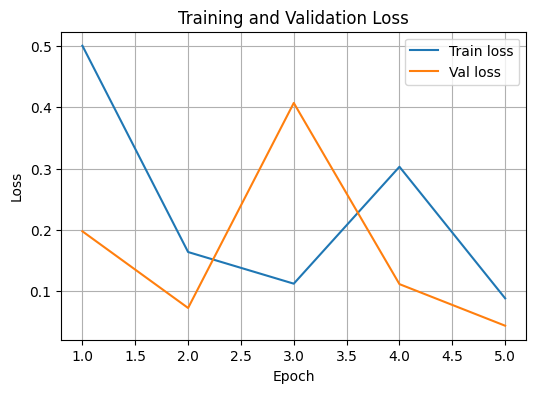

In [ ]:
# Plot training and validation loss curves
# This helps to visually check if the model is overfitting or improving.

# === Plot training and validation loss curves ===

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## 7. Evaluation on the test set

To quantitatively measure model performance, we define `evaluate_accuracy(df, max_samples)`:

For each sample in the given DataFrame, it:

1. Reads the ground truth string from `df["text"]`.
2. Uses `predict_text(image_path)` to generate the model prediction.
3. Normalizes both strings to lower-case for fair comparison.
4. Computes two metrics:

### 7.1 Word-level accuracy

- Counts how many predictions exactly match the ground truth string.
- This is a strict metric: the entire text must be identical.
- Reported as a percentage of total samples.

### 7.2 Character-level accuracy

- Compares each character between ground truth and prediction.
- Computes the ratio:

  \[
  \text{char\_acc} = \frac{\text{number of matching characters}}{\text{total number of compared characters}}
  \]

- This metric is more tolerant:
  - small spelling differences still give partial credit.

When running:

```python
word_acc, char_acc = evaluate_accuracy(test_df, max_samples=100)


In [ ]:
from tqdm.auto import tqdm

# Define evaluation metrics on a DataFrame (test or validation)
# It measures:
#   - word-level accuracy  (exact string match)
#   - character-level accuracy (per-character agreement)

def evaluate_accuracy(df, max_samples=None):
    # Optionally evaluate on a subset of the data for speed
    if max_samples is not None:
        df = df.sample(max_samples, random_state=0).reset_index(drop=True)

    total = 0
    exact_match = 0
    char_correct = 0
    char_total = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Evaluating"):
        gt = str(row["text"]).strip()
        pred = predict_text(row["image_path"]).strip()

        # Normalize: lower-case for easier comparison
        gt_norm = gt.lower()
        pred_norm = pred.lower()

        # 1) Word-level exact match
        if pred_norm == gt_norm:
            exact_match += 1

        # 2) Character-level accuracy
        max_len = max(len(gt_norm), len(pred_norm))
        for i in range(max_len):
            gch = gt_norm[i] if i < len(gt_norm) else ""
            pch = pred_norm[i] if i < len(pred_norm) else ""
            if gch == pch:
                char_correct += 1
            char_total += 1

        total += 1

    word_acc = exact_match / max(1, total)
    char_acc = char_correct / max(1, char_total)

    print(f"Word-level accuracy : {word_acc:.2%}")
    print(f"Char-level accuracy : {char_acc:.2%}")

    return word_acc, char_acc

# Evaluate on the test set (you can limit max_samples if it's large)
word_acc, char_acc = evaluate_accuracy(test_df, max_samples=100)


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Word-level accuracy : 92.00%
Char-level accuracy : 93.91%


we evaluate the model on a random subset of 100 test samples, and obtain:
- Word-level accuracy ≈ 92%
- Character-level accuracy ≈ 93.91%

These results indicate that, for most test images, the model predicts exactly the correct medicine name.
Even when the full word is not perfect, the majority of individual characters are recognized correctly.


## 8. Loading the best fine-tuned checkpoint

After training multiple epochs, we may want to reload the model from the **best epoch**  
(for example, the epoch with the lowest validation loss).

In this section:

- We set `MODEL_DIR` to the folder of a chosen epoch (e.g. `trocr_finetuned_epoch5`).
- We reload both:
  - the `processor` (for preprocessing),
  - and the `model` (fine-tuned weights).
- We define `predict_text(image_path)` again so that it uses this checkpoint for inference.

This allows us to:
- run evaluation and visualization using the selected fine-tuned model,
- without needing to re-run the whole training loop.


In [ ]:
# Load a specific fine-tuned model checkpoint from disk.
# Change MODEL_DIR to the epoch you want to use for evaluation.

from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch
import os

MODEL_DIR = "/content/drive/MyDrive/datasetmidcal/trocr_finetuned_epoch5"

processor = TrOCRProcessor.from_pretrained(MODEL_DIR)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fea

In [ ]:
# Helper function to run inference with the (fine-tuned) model

def predict_text(image_path, max_len=32):
    image = Image.open(image_path).convert("RGB")

    with torch.inference_mode():
        pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
        generated_ids = model.generate(pixel_values, max_new_tokens=max_len)
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return pred


## 9. Qualitative results: visualizing predictions

Finally, we visualize how well the model reads real prescription images.

The helper function `show_prediction(row)`:

1. Opens the image at `row["image_path"]`.
2. Displays it using `matplotlib`.
3. Shows:
   - **GT**: the ground truth text (medicine name),
   - **Pred**: the model’s predicted text.

We then sample a few random rows from `val_df` (or `test_df`) and call `show_prediction` on each one.

These examples provide **qualitative evidence** of performance:
- When **GT and Pred match**, the model is correctly reading the handwriting.
- When they differ, we can visually inspect whether the mistake is due to:
  - very messy handwriting,
  - ambiguous letters,
  - or a remaining limitation of the model.

Together with the numerical metrics (loss curves, word/char accuracy),
these visualizations complete the evaluation of the fine-tuned OCR system.


In [ ]:
# Visualize an example: display image, ground truth, and prediction
import matplotlib.pyplot as plt

def show_prediction(row):
  """
    Display a prescription image and overlay:
      - GT   : the ground truth text (label)
      - Pred : the model prediction

    Args:
        row (pd.Series): one row from train_df / val_df / test_df
                         containing 'image_path' and 'text'.
    """
    img_path = row["image_path"]
    gt = row["text"]
    pred = predict_text(img_path)

    plt.figure(figsize=(6, 6))
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"GT: {gt}\nPred: {pred}", fontsize=12)
    plt.show()


Show some random validation samples

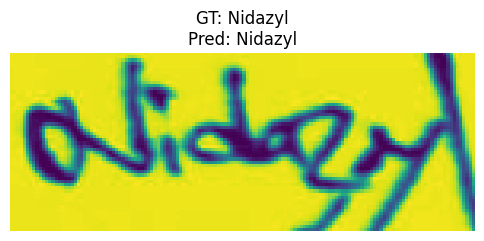

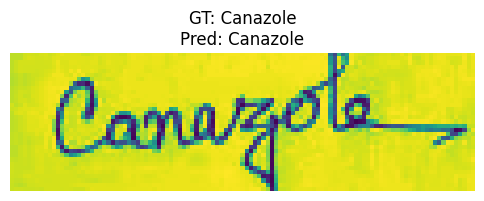

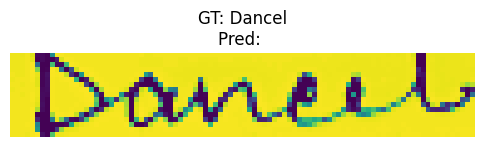

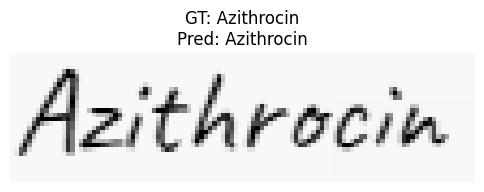

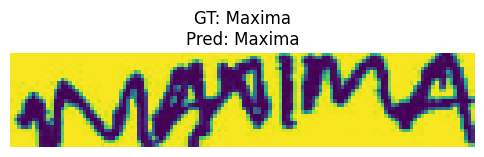

In [ ]:
# Show a few random validation images with model predictions.
# This gives qualitative insight into how well the model is reading handwriting.

sample = val_df.sample(5, random_state=42)
for _, row in sample.iterrows():
    show_prediction(row)
